# Group 38 - Abigail Caddick, Rebekah Lee, and Lauriston Prescott Jr

# Project Final Report

### Due: 11:59pm on August 9th (with a two hour + one minute grace period) — 50 points  

### No late submissions will be accepted.


Complete all sections of this notebook to document your final decisions, results, and broader context.

You will write a **technical report** following standard conventions. Useful references include:
- [CMU guide to structure](https://www.stat.cmu.edu/~brian/701/notes/paper-structure.pdf)
- [Data science report example](https://www.projectpro.io/article/data-science-project-report/620)
- The Checklist in this week’s Blackboard Lesson (aligned with HOML)

Your audience is **technically literate but unfamiliar with your work**—for example, your manager or other data scientists. Your report should be clear, precise, and well-organized, combining explanation, visualizations, and interpretation.

This Final Report is distinct from Milestone 2:

- **Milestone 2** serves as a repository of your working code and experiments  
- **This Final Report** presents a clear, structured summary of your project for a professional audience  

> **Important:**
> - Do **not** assume that readers of this report are familiar with Milestone 2. Your report should stand on its own.
> - Do not include code, code screenshots, or code cells in this notebook. All code was submitted in Milestone 2. This report should focus on explanation, results, and interpretation.
> - **Do not add, delete, or move cells in this notebook.** Each answer must be written entirely within its assigned Markdown cell.
> - All answers should be inserted directly under the appropriate `Answer:` prompt. Delete the sentence "Replace this sentence with your answer in this cell--do not add additional cells" and replace it with your response.
> - You may use any appropriate Markdown formatting (paragraphs, lists, tables, inserted graphics, LaTeX, etc.).
> - Submit this notebook as a group via your team leader’s Gradescope account.




## Submission Checklist

- Final Report Notebook — submitted by team leader  
- **DO NOT SUBMIT Word or PDF files!**



## 1. Executive Summary [4 points]

Write a 300–400 word executive summary for a **non-technical audience**, such as business stakeholders in a real estate company.

Your summary should explain:
- the objective of the project
- key insights about the data
- the most important findings, including a plain-language description of model performance
- a clear recommendation or takeaway

Avoid technical detail and jargon. Focus on what matters and why.

**1.1 Answer:**  

> Our team used 2016 housing data provided by Zillow to build predictive models for properties’ assessed tax values. These models may prove to be useful screening tools for potential properties which will reduce the time our team spends manually reviewing individual properties. Manual review is quite time-consuming, so our proposed models will allow the team to dedicate more of their time to more important tasks.

> Our dataset included information for 77,613 homes across 55 columns, but due to a high percentage of missing or uninformative data, this was reduced to 60,966 homes across 36 features. Due to computational limitations, we had to exclude several features which may have impacted our model's performance. When evaluating the data, we chose metrics which would maintain interpretability across teams. The baseline Random Forest’s predicted assessed tax values differed from actual assessed values by about \$204,000 on average. Our Random Forest models also consistently produced lower prediction errors than the Linear and Ridge alternatives. Initially, we selected our baseline Random Forest as our final model. We also evaluated several modelling techniques to see if we could further bridge the gap between actual and estimated assessed tax value; after further evaluations, our team has decided that these tuning techniques offered the best overall balance of prediction accuracy, stability, and expected generalization to new data. The tuned Random Forest, however, was not used in the final held-out test evaluation because we had initially selected the baseline Random Forest based primarily on its cross-validation error.

> We would recommend moving forward with the tuned Random Forest model as it provided the best overall balance. Additional investment in data collection and computational resources may further improve future predictions. As this model has not been fully tested on unseen data, we would need to complete further testing and maintain a level of human oversight during initial deployment. The current model can be used as a screening tool to reduce the need for complete manual review of properties. Future improvements may allow for additional functionality of the model and potentially further reduce the need for human oversight.


## 2. Introduction [3 points]

Introduce the topic, context, and goals of your project.

You may imagine that this project was completed for a **real estate company with a small in-house data science team**.

Include all of the following:

- Clearly introduce the topic and context of your project
- Describe the problem you are addressing (the problem statement) and the overall motivation for solving it
- Clearly state the objectives and goals of your analysis (as different from the motivation)

**2.1 Answer:**  

> Our team evaluated housing data from 2016 provided by Zillow to see how accurately a property's assessed tax value could be predicted based on the information provided by Zillow in the listing. Assessed tax value is incredibly nuanced as it depends not only on the specifics of each property, but also their geographical location. When looking at location, the price of similar properties may drive pricing and thus tax value. As manual evaluation of each property is very time consuming, we developed different models to see if this process could be streamlined. If predictions were found to be accurate, this would help guide the decisions our real estate agents make. Impacted decisions may include property evaluation, comparison, screening, and flagging potentially unusual assessments. Inaccurate predictions may reflect limitations of the data provided or suggest alternative modelling approaches. If subsequent approaches are unable to make accurate predictions, we may choose to explore alternative data sources that may contain data with fewer limitations.

> Our detailed analysis began with an exploratory analysis of the raw data which helped to guide preprocessing choices pertaining to data usefulness, potential predictive value, and computational costs. We then explored feature engineering and hyperparameter tuning before selecting our final model based on its predictive accuracy, stability, and generalization. This model was then tested on a held-out set of data to see how it would perform on unseen data.

## 3. Data Description [3 points]

Describe the dataset used in your analysis.

Include:
- the source of the dataset
- the number of observations (samples) and features
- the types of variables
- the target variable
- missing values or other important issues in the raw data

**3.1 Answer:**  

> For both milestone 1 and 2 we cleaned and ran models on a reduced version of the Zillow housing dataset used in the Zillow Prize competition on Kaggle in 2017. This dataset contains 77613 rows spanning across 55 columns. The features can be categorized further into 28 numerical, 24 nominal, and 2 ordinal. Our target variable is the property's assessed tax value (taxvaluedollarcnt).

> During our exploratory analysis of the dataset, we identified several important issues in the raw data that needed to be resolved prior to full analysis. To begin, out of the 55 features 20 of them were missing more than 90% of entries. There were an additional 9 features missing between 60-89% of entries. The target had 35 missing entries as well. Additionally, there were several features that were deemed to be either useless, duplicated, or had too many unique values to provide helpful insight. The parcelid and assessmentyear were deemed useless as parcelid is only an identifier and the only assessmentyear recorded was 2016. As mentioned, many features included duplicated data such as: fips and regionidcounty (both are county identifiers), rawcensustractandblock and censustractandblock (both are census tracts). There were similar instances of redundant data within the squarefeet, bathroom, pool, and fireplace related features. Lastly, we identified features that may be useless due to their unique value count, such as parcelid and censustractandblock both of which had over 30,000 unique entries. We also evaluated features with few unique values, such as assessmentyear or hashottuborspa which only had 1 unique value each.


## 4. Methodology (What you did, and why) [20 points]

Focus on the **process and your reasoning**, not the results.

Note: Each subsection (e.g., 4.1, 4.2, etc.) must be answered in its own Markdown cell.  Each subsection is worth 5 points.

### 4.1 Analytical Framework

Describe the overall framework you used to develop, compare, and evaluate your models.

This section should explain the structure of your model-development process: what procedures you used, how the stages fit together, and how modeling decisions were made.

> Present the detailed plots, tables, and numerical evidence supporting those decisions later in Section 5.2.

Include:

- how the data were used for training, validation, and final testing,
- the primary evaluation metric you selected, such as MAE or RMSE, and why it was appropriate,
- the procedure you used to compare alternative models, preprocessing choices, and hyperparameter settings, and
- how validation methods, such as cross-validation, validation curves, RandomizedSearch, or Optuna, were incorporated into the model-development process.


**4.1 Answer:**

> When considering how to preprocess our data, we began by evaluating each of the features individually. We evaluated features based on: missingness, identificators, redundancy, computational cost; as well as whether features would require encoding, imputation, or scaling. Section 4.2 discusses our reasoning for missingness, identificators, and redundancy. We also explored feature selection which will be discussed in detail in section 4.3

>> Prior to building models, we imputed missing data based on its data type - numerical features were imputed with SimpleImputer(strategy='median'). Categorical features were imputed with the most frequent value.

>> Our nominal and ordinal features were both encoded. The nominal features first used pd.get_dummies() and aligned to the training columns using reindex() before we employed one hot encoding whereas the ordinal features utilized OrdinalEncoder. Numerical features were not encoded. For some features, such as longitude and latitude, we explored used frequency encoding - this is discussed further within the feature engineering section of this question.

>> Some model choices, such as Ridge regression, required scaling of features. The scaling was done within a pipeline.  

>> As the project progressed, some features caused substantial computational costs - we then evaluated those features to determine if the meaning they provided the model were likely to be meaningufl or not. Some features, such as propertyzoningdesc, were dropped to reduce the computational cost of the model.

> To evaluate generalization of our models, we set aside 20% of the samples into a test set. The test set was held out and not used to compare models or to make feature engineering or hyperparameter choices; it was only evaluated on our final model choice. Within the training set, we used repeated 5-fold cross validation in all model iterations. The use of a training split with cross validation with our scoring metrics, discussed below, ensured model performance was evaluated in the same manner. The Ridge model's use of scaling within a pipeline ensured that there was no data leakage within the cross validation training folds. For all models, we used a fixed random state to ensure results would be consistent between run-times.

> Our primary evaluation metric was CV MAE. We chose to use MAE over other metrics, such as RMSE, as it does not give disproportionate weight to larger errors and can maintain the original dollar unit which often makes it easier to interpret. For some models, we also looked at the train MAE to evaluate for over or underfitting. For all models we also looked at the CV STD to evaluate the stability and spread of the models.

> Once our baseline Linear, Ridge, and Random forest models were built, we evaluated them based on train MAE, CV MAE, and CV STD. This evaluation drove our future choices for both feature engineering and hyperparameter tuning.

> We attempted several methods of feature engineering which were all evaluated based on their CV MAE, STD, and computational cost when necessary. We compared log transformation, normalization, binning, and frequency encoding.

>> Log transformations were tested on all 3 models and their CV MAE and STD were compared to the baseline results. We tried two variations of log transformations - the first where only the target was log-transformed, and the second where both the features and the target were log-transformed. The target only version used a TransformedTargetRegressor - this was used in all 3 model types. The combination log-transformation process used a ColumnTransformer and FunctionTransformer within a Pipeline and then the Pipeline was wrapped within a TransformedTargetRegressor. As the transformation was done within a Pipeline it prevented data leakage within each CV training fold.

>> Normalization was explored using a StandardScaler within a Pipeline. As the scaler was within the Pipeline, it protected against data leakage.

>> Binning proved to cause excessive RAM usage and thus was not employed in the final version of the project. We instead chose to use frequency encoding.

>> Frequency encoding was used for columns such as latitude and longitude as other processing techniques, such as binning or log transformations, were either too computationally costly or did not make sense for the data type. For each selected feature, we created a new frequency variation of the feature representing the proportion of training observations containing each unique value.

> Hyperparameter testing was employed on the top feature engineering model choices. This testing varied by model type, but each used a 5-fold cv GridSearchCV was search for the best parameters of each model. Once the optimal hyperparameters were found, we then created a new model based on those parameters and evaluated them based on the train MAE, CV MAE, and CV STD.

>> The linear model tested whether fit_intercept = True or False produced the best, most stable results. Fit intercept was appropriate to evaluate as it controls whether the model estimates an intercept or forces the regression line through zero. There are few other meaningful hyperparameters utilized in a standard linear regression so this was the only parameter evaluated. Tuning did not meaningfully improve model performance.

>> Ridge models main tuning parameter is its alpha value, so our hyperparameter search focused on trying different alpha values as those control the strength of the regularization within the model. We chose to begin a broad search of alpha values (0.01, 0.1, 1, 10, 100, 1000). We used the best alpha from the broad search, 100, to run a more focused search of alpha values (50, 75, 100, 150, 250, 500, 750). Tuning showed a modestly improved model.

>> Of the three model choices, Random Forests gave us the most opportunity for hyperparameter tuning. We chose to focus on max depth and max features. Prior versions of the random forest models indicated that there was overfitting so our choice of hyperparameters reflects our goal of improving model stability and generalization. We also used both a broad and narrow grid search to more easily hone in on the optimal parameters. Our broad search consisted of max depth (None, 5, 15, and 30) and max features (sqrt, .2, .5, 1.0). The results of our broad search guided our focused search to explore max depth (10, 15, 20) and max features (0.4, 0.5, 0.6). Tuning produced a modestly improved model, but comparison to the training MAE showed that it was still overfitting.

### 4.2 Data Cleaning and Preprocessing

Describe how you cleaned and prepared the raw data for modeling.

Focus on the problems you encountered, the procedures you considered, and the reasoning behind your final preprocessing choices. Detailed plots, tables, and numerical comparisons supporting these decisions should be presented later in Section 5.2.

Include:

* important issues in the raw data, such as missing values, outliers, inconsistencies, or unusable features,
* how you addressed those issues,
* the preprocessing alternatives you considered,
* which procedures you retained for the final analysis and why, and
* which procedures you rejected or changed and why.



**4.2 Answer:**

> The exploratory analysis of the raw data highlighted several important issues that needed to be evaluated during preprocessing. These issues included: missingness, outliers, and inconsistencies.
>> The handling of missing data had a two-fold approach - first, we looked at features with many missing values, then we looked at rows with missing data. We determined that there were 20 features missing more than 90% of entries and an additional 9 features missing between 60-89% of entries. We decided to drop nearly all of these features with the exception of fireplacecnt, poolcnt, and taxdelinquencyflag as a lack of response to these features did not inherently imply that the data was missing. When addressing individual rows of data, we decided to drop any rows with either a missing target entry or more than 25% of missing entries amongst all features.

>> When exploring the data for outliers, there were very few features with high percentages of outliers. There were only six total features with a percentage of outliers greater than 10% with propertylandusetypeid having the highest percentage of outliers at 28.49%; however, as this is an identification feature it is unlikely for this to be a true outlier. In fact, of those six features, four of them were related to either identifiers or geographical region. The additional two features, lotsizesquarefeet and roomcnt, may have represented real data for properties that was unusual within the population and their exclusion could have introduced bias to the model.

>> There were a few notable inconsistencies within the data. The largest was that there were several features erroneously identified as being floats instead of strings or objects (such as ID features). To handle these, we assigned them to our list of categorical columns prior to imputation and encoding. When using pd.get_dummies we avoided feature mismatch between the test and train sets by using reindex(). Lastly, the feature taxdelinquencyflag had inconsistent data with the only entries being "Y" or "NaN" - there was no "N" option; this required categorical imputation and encoding.

> Throughout our preprocessing and model iterations we attempted several strategies for handling the data. Some of these strategies were implemented throughout the project whilst others were abandoned. The runtimes of our baseline models were taking several hours which prompted us to remove high-cardinality features to reduce RAM usage - this alternative strategy was employed for every model iteration. When exploring feature engineering, we attempted binning but this proved to also have a high computational cost and thus was abandoned.

> Our final model retained the majority of our preprocessing choices - dropping of missing features or rows, imputation, encoding, keeping outliers, use of default settings, and a random_state. We believe that these choices gave us the best balance of data integrity and model efficiency.

> Sections 4.1 and 4.3 discuss several hyperparameter and feature engineering model choices. Our inital final model did not employ every one of those strategies as we were choosing our model based on the best CV MAE. The explored options we excluded were log transformations, scaling, binning, frequency encoding, and random forest feature selection. As described in section 4.4, we later decided to take a more nuanced approach than CV MAE alone, and instead evaluted the train-to-CV MAE gap and fold-to-fold stability of the CV MAE STD.

### 4.3 Feature Engineering

Describe the feature transformations and new features you considered during model development.

Focus on what you tried, the purpose of each change, and the reasoning behind the features you ultimately retained. Detailed evidence comparing these choices should be presented later in Section 5.2.

Include:

* transformations applied to existing features,
* new features created from the available data,
* the motivation for each transformation or new feature,
* which features or transformations you retained and why, and
* which features or transformations you rejected and why.


**4.3 Answer:**

> For the housing dataset we explored transformations applied to existing features. We explored log transformation on only the target variable as well as the selected continuous predictors and the target variable, normalization using the standard scaler, and frequency encoding. Originally we also looked into the effects of binning the continuous features; even though there was a substantial drop in the model's cross validation MAE it was not retained for adding too much complexity to the model which resulted in extensive computational cost. The data contained many outliers which we believed to be real documented values, so instead of removing useful information we choose transformations that can handle them. This allowed us to maintain valuable information while reducing the influence of skewed results.

> Log transformation was the first method explored to accomplish this goal; when transforming only the target feature, the model overshot when in log scale, and when transformed back to the units of the target variable the errors were astronomical. This led us to abandon this approach for all models. We then performed log-transformations on both continuous predictors and the target which produced varying results. Both the Linear and Ridge models were able to make predictions on a more balanced scale showing CV MAE improvement, whereas the Random Forest model performed slightly worse than baseline. The log transformations of the Linear and Ridge models were the only methods of feature engineering retained for final model selection.

> We then wanted to experiment with having all features on the same scale, so we used StandardScaler to center the features around a mean of 0 based on their standard deviation. This resulted in negligiable changes in the Linear model and a worse CV MAE in the Random Forest. The baseline Ridge model already incorporated a StandardScaler, so there was no change in performance. As this did not meaningfully improve any of the models, this was not incorporated into any subsequent models.

> Certain continuous features such as 'latitude' or 'yearbuilt' were not interpretable on a log scale, so we attemped binning. Binning grouped these selected continuous values into interpretable ranges, but one-hot encoding the resulting categories substantially expanded the feature set and increased computational cost. Although this proved effective we did not retain this transformation for the added complexity and computational cost. To try to offset this, we employed frequency encoding which increased the MAE of all three models thus proving to be ineffective.

> Feature engineering had mixed results across our models - some methods showed modest improvements in the Linear and Ridge models whereas Random Forest was not improved. While methods such as binning were successful in reducing the CV MAE, the computational cost outweighed the improvements and the transformation was not retained. The feature and target log transformations were retained in our final model selection choices for both Linear and Ridge whereas hyperparameter tuning proved to be more effective for the Random Forest model.

### 4.4 Model Selection

Describe how you selected your model.

Include:
- models you tried and why
- how you evaluated generalization
- how validation results were used to compare models and hyperparameters
- how the test set was reserved for the final evaluation of the selected model
- any important trade-offs you considered, such as predictive performance, computational cost, interpretability, or model complexity

**4.4 Answer:** 

> The final model was selected by comparing the Linear Regression, Ridge Regression, and Random Forest Regressor. Repeated 5-fold cross-validation was performed on the training data to make sure that model comparisons were not influenced by the variability of a single split. MAE served as the primary evaluation metric because it is directly interpretable as the magnitude of an assessed-value prediction error and is less sensitive than RMSE to the strong right skew observed in the target. While CV MAE served as the primary evaluation metric, we also used the train-to-CV gap and CV MAE STD as supporting measures of generalization and stability. Our initial final model was the baseline Random Forest, but upon further evaluation we have revised it to be the tuned Random Forest. This change will be discussed in more detail below.

> Generalization was evaluated by comparing a model's training MAE to its cross-validated MAE. A large gap between these metrics indicated overfitting, whereas a small gap suggested the model was generalizing better. Among the baseline models, the Random Forest achieved the lowest cross-validated MAE, but also exhibited the largest train vs CV gap, flagging it as likely to overfit. This comparison was established in the baseline models and continued into our final model comparison.

> Validation results were also used to guide hyperparameter tuning: we ran a broad grid search for Ridge and Random Forest, then used the top-performing region of the broad search to run a narrower, focused search. Linear Regression offered essentially one hyperparameter, so tuning there was limited. In every case, models and hyperparameter settings were primarily ranked using cross-validated MAE. During our final review, train-to-CV gaps and CV MAE standard deviations were also considered when evaluating overfitting and stability. Only after we had settled on the baseline Random Forest as the initial final model, with default hyperparameters, did we retrain it on the full training set and evaluate it a single time on the untouched test set, so that our reported test performance would be an honest estimate of generalization.

> The primary trade-off we considered was between predictive accuracy and factors such as interpretability, computational cost, and the risk of overfitting. Random Forest is more challenging to interpret, requires greater computational resources for training and tuning, and exhibited clear overfitting, as indicated by a lower training MAE compared to its cross-validation MAE. Ridge Regression was straightforward, computationally efficient, stable, and easily communicated to stakeholders. We ultimately prioritized predictive accuracy. The baseline Random Forest's approximately \$27,000 cross-validation MAE improvement over the tuned linear models was substantial relative to the typical scale of assessed tax values. The tuned Random Forest performed similarly, with an approximate improvement of \$28,000. Therefore, we determined that the gain in accuracy justified the increased complexity and reduced transparency.

> In Milestone 2, we selected the baseline Random Forest as our final model. Among our baseline models, the Random Forest had the lowest CV MAE. The baseline was also slightly more stable across folds than the tuned version. However, upon further evaluation we changed our final model recommendation to the tuned Random Forest. The tuned version of the Random Forest had a lower CV MAE, smaller train-to-CV gap, and a slightly higher CV MAE STD (increased by \$59.06). While the CV MAE STD was slightly higher, it was still stable across folds. We determined that the improvement in CV MAE outweighed the modest decrease in fold-to-fold stability. While we have changed our recommendation, it was not evaluated on the held-out test set, so its final out-of-sample performance remains unconfirmed. As we ran the baseline Random Forest on the test set, the test set no longer remains untouched. This updated recommendation provides a more nuanced, well-rounded evaluation compared to using CV MAE alone.

## 5. Results and Evaluation (What you found, and how well it worked) [16 points]

Focus on **results, evidence, and interpretation**.

Note: Each subsection (e.g., 5.1, 5.2, etc.) must be answered in its own Markdown cell.

### 5.1 Model Performance (8 points)

Present and interpret the performance of your selected final model.

Include:

* the final model you selected,
* its performance on the final test set using your primary evaluation metric,
* a practical interpretation of what that error means in the context of the project,
* relevant supporting metrics, such as MAE, RMSE, or $R^2$,
* a comparison with the most important alternative models, and
* a comparison of training, validation, and final test performance to identify possible underfitting, overfitting, or discrepancies between validation and test results.

Focus on the most informative results rather than reporting every metric or model considered.


**5.1 Answer:** 

> Our initially selected final model was the baseline Random Forest Regressor, trained with scikit-learn's default hyperparameters. On the held-out test set, which had not been used during the original model-selection or tuning process, this model achieved a final test MAE of approximately \$204k.

>> On average, the model's predicted assessed tax value differs from the true value by about $204k. While this is a substantial absolute error, we do not recommend using the model as a stand-alone valuation tool. However, compared to the larger errors from alternative models and considering the wide range of assessed values in the dataset, this level of accuracy remains useful for triage tasks described in Section 2.1, such as comparing properties, screening listings, or flagging assessments for further review.

>> MAE was the only metric we tracked throughout this project, so our supporting evidence comes from comparing MAE and its standard deviation across data splits. On the training data used to build the initially selected baseline model, Random Forest's own train MAE was \$76,334.87, while its mean cross-validated MAE was \$203,166.49 with a standard deviation of only \$3,839.66. The small CV standard deviation tells us the model's validation performance was very consistent across folds, even though the large gap between train MAE and CV MAE indicates the model is overfitting the training data to some degree.

>> Evaluating training, validation, and test performance together provides a more comprehensive assessment than any single metric. The training MAE (\$76k) is substantially lower than both the cross-validated MAE (\$203k) and the final test MAE (approximately \$204k), indicating overfitting to the training data. However, the close alignment of the CV MAE and test MAE indicates that cross-validation provided a reasonable estimate of the baseline model’s performance on the held-out test data.

>> Against the alternative models, Random Forest’s cross-validated performance was a clear improvement. After tuning, our final Linear Regression model had a CV MAE of \$229k  and our final Ridge Regression model had a CV MAE of \$230k. Both linear models had much smaller train-to-CV gaps, indicating less overfitting, and slightly lower CV MAE standard deviations. However, the Random Forest’s CV MAE was still roughly \$26,000-27,000 lower than either model's.

> The reported held-out test results belong to the baseline Random Forest selected during Milestone 2. Although subsequent review led us to recommend the tuned Random Forest based on its stronger cross-validation results and smaller train-to-CV gap, the tuned model was not evaluated on the held-out test set. This change was discussed above in Section 4.4.

>> The tuned Random Forest had a mean cross-validated MAE of $201,725.50. Its train MAE was \$106,016.50 - showing an improvement in the train-to-cv gap of the baseline Random Forest. Additionally, its stability was modestly worse than at baseline (a difference of about \$59). Random Forest still showed evidence of overfitting, tuning resulted in a lower CV MAE and reduced the train-to-CV gap, indicating improved generalization compared with the baseline model.

### 5.2 Visualizations and Summaries (6 points)

Present at least two clearly labeled visualizations or quantitative summaries that provide meaningful evidence for important modeling decisions or conclusions.

Include plots, tables, or outputs from automated hyperparameter search tools that help demonstrate why particular models, preprocessing choices, features, or hyperparameter settings were retained or rejected.

Insert plots and graphical outputs as clear images directly into the Markdown cell. Tables and concise quantitative summaries may be created using Markdown. Do not include code or code cells. Crop screenshots so that only the relevant material is shown, and ensure that all labels and values are readable.

Each element must be clearly labeled and discussed in the text. Explain what it shows, what conclusion you draw from it, and how it supports a specific modeling decision.

Notes:

* You are not required to include any particular type of plot, such as a validation curve.
* If you used automated methods such as RandomizedSearch or Optuna, include summaries, comparisons, or plots that provide evidence for your model or parameter choices.
* Focus on the most informative evidence rather than including every plot or output produced during Milestone 2.
* The goal is to communicate and justify your decisions, not to reproduce your experimental notebook.


**5.2 Answer:**  

> 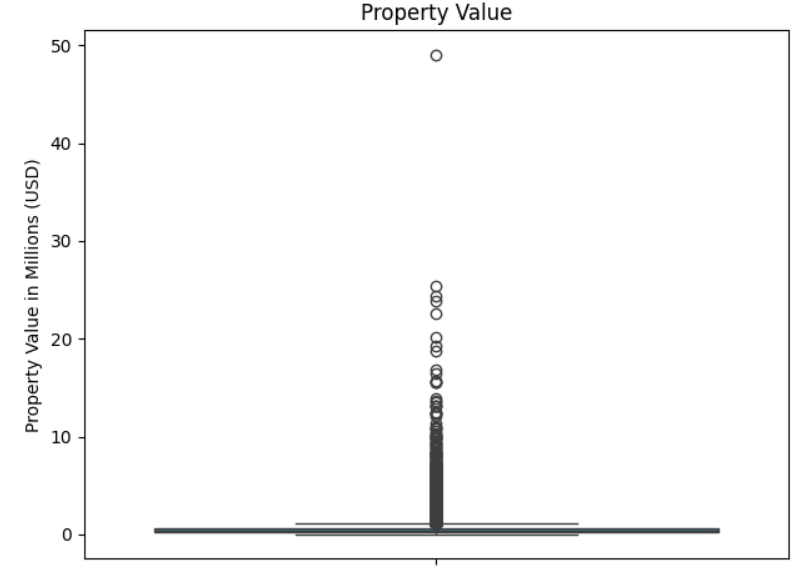
>
>This graphic shows a box plot for our target variable 'taxvaluedollarcnt'. The objective of creating this visual was to see how many outliers were present within the target feature during the preprocessing step in Milestone 1. The importance of this graph is to validate the need of feature engineering techniques with the data we were given. With so many outliers present we did not want this to impact the prediction accuracy of our models, especially for linear regression which is very sensitive to outliers both in the input features and target value. By finding a technique that handles the outliers instead of removing them we were able to keep the information and create a more diverse model. With the use of log transformation in both the continuous features and target variables the models which are affected by the shown outliers (linear and ridge regression) were not as sensitive or skewed.

>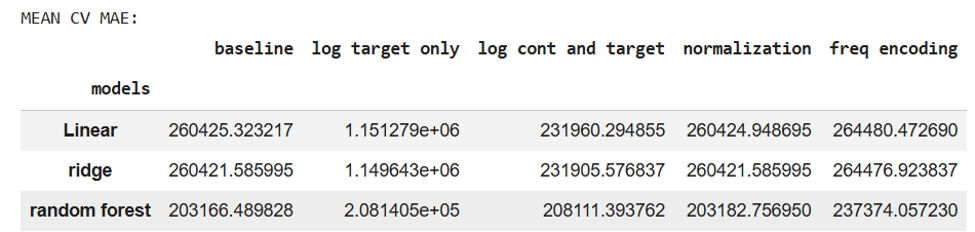

>This table shows the difference in the cross validation MAE for each model after utilizing several feature engineering techniques. As seen, our linear regression model and ridge regression model benefitted from these transformations the most with the most significant drops in CV MAE, but both saw an increase in the standard deviation which was later brought back down by feature selection. Our chosen model, the random forest regressor was uneffected by all explored transformations as well as feature selection. The lowest MAE consistently proved to be our baseline model with $203,166.49. Normalization was the closest to having an effect on the model, but because this model is less sensitive to outliers normalization did not have a significant effect. Because there was no improvement we did not retain any feature engineering techniques for our final random forest regressor model.


>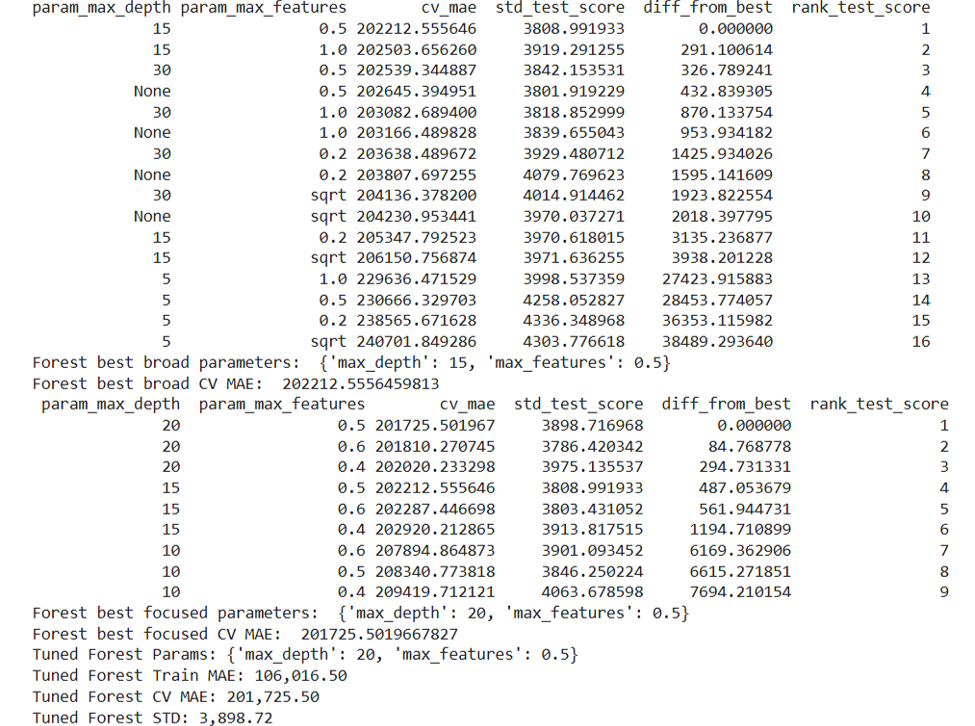

> We began by running a broad GridSearchCV on the hyperparameters max_depth and max_features. The results of this search were printed in a table showing the combinations of parameters used in the search, their CV MAE and standard deviation of the CV MAE, how the MAE results differ from the best results of the search, and a ranking of their CV MAE performance. Below the table you will find the best tested parameter combination from this broad search as well as the corresponding CV MAE. The results of this broad search were used to run a more focused GridSearchCV whose results are also depicted in the image. As shown, the broad search had a wider range of parameters and more combinations were tested. The focused search showed that the best tested values were max_depth = 20 and max_features = 0.5. These parameters resulted in a train MAE of \$106,016.50, CV MAE of \$201,725.50, and STD of \$3,898.72. This tuned version of the model did modestly lower its CV MAE while its STD was higher than seen in any other Random Forest model explored. While the STD of this model was higher than other Random Forest models, it was still stable across folds. Compared to the baseline Random Forest model, the degree of overfitting was reduced; however, the comparison between train and CV MAE shows that this model was still overfitting.

> We initially chose the baseline Random Forest as our final model. The tuned Random Forest's CV MAE showed an improvement of \$1,441 whereas the baseline Random Forest's CV MAE STD showed it was modestly more stable than the tuned version. Both models showed signs of overfitting, but the tuned model showed improvement in this regard - reducing the gap from \$126k to \$95k. The baseline model was initially chosen as the CV MAE only modestly improved with tuning; however, after further review, we decided that utilizing a more nuanced approach was more appropriate for our final model recommendation. Therefore, we would suggest instead using the tuned Random Forest model moving forward. The tuned model was not evaluated on the held-out test set. Please refer to Section 4.4 for a more detailed justification of this change.

### 5.3 Model Limitations (2 points)

Discuss the most important limitations or weaknesses of your final model.

Base your discussion on the results and analyses completed in Milestone 2. You are not required to conduct new modeling experiments for this section, although you may include an additional numerical summary or visualization if it helps clarify your conclusions.

Include, as appropriate:

- evidence of underfitting, overfitting, instability, or differences among - training, validation, and test performance,
- types of observations or properties that may be especially difficult to predict,
- plausible explanations for the model’s limitations, and
- one or more potential changes that might improve future performance.

Focus on interpreting the model’s limitations rather than merely restating its performance metrics.

**5.3 Answer:**  

> Our initial model's primary limitations were overfitting and RAM capacity. Fortunately, the model was stable across folds and both the cross-validation and test MAE were very similar; an unstable model that was also overfitting would be more worrisome. Upon further review, we decided to change our recommended model to the tuned Random Forest. The main limitation of this model is that it has not been tested on the held-out test set, so its performance is unconfirmed. While the tuned Random Forest improved the train-to-CV MAE gap, there were still indications that this model was overfitting. These limitations may make certain properties harder to predict in the future; specifically, we believe the models may have difficulty in predicting the assessed tax value of properties with outlying features (such as large numbers of rooms, large lot sizes, or more rare combinations of property characteristics) as well as properties whose data required imputation due to missing data. There are several potential explanations for these limitations. The raw dataset contained many rows and features with missing data - a more complete dataset may have yielded better results. Additionally, our RAM capacity substantially limited the number of features we were able to include in all models as well as our ability to tune hyperparameters, which may indicate that an upgrade to our system is reasonable. In the future, we may also consider trying different model types, such as HistGradientBoostingRegressor, or breaking the data into smaller property groups, such as using DBSCAN to create clusters based on location, and running models on each individual property group.


## 6. Conclusion [4 points]

Summarize the main findings and implications of your analysis. This section should not simply repeat the Executive Summary. It is written for a technical audience that has read the full report and should synthesize the evidence, limitations, and practical significance of your work.

Include all of the following:

* clearly state your main findings and explain how they address the original project objectives,
* highlight the business or practical implications of those findings,
* discuss the limitations and constraints of your analysis clearly and transparently,
* suggest potential improvements or directions for future work, and
* conclude with a final recommendation that addresses the original business objective.


**6.1 Answer:**  

> We found that the best model to predict the assessed tax value of homes in the Zillow Housing Dataset was a Random Forest regressor. We used the mean absolute error as our primary evaluation metric and reported \$203,910.90 in our initially chosen final model. Per our updated recommended model, our evaluation metrics were CV MAE, train-to-CV MAE difference, and CV MAE STD. In all three model types explored we applied feature engineering techniques such as log transformation, standardization, and frequency encoding. All listed techniques increased the Random Forest’s CV MAE and therefore were rejected. Our final Random Forest regressor model utilized hyperparameter tuning which resulted in the lowest CV MAE and had a lower train-to-CV MAE gap than the baseline Random Forest. The tuned model was not evaluated on the held-out test set, so its independent out-of-sample performance remains unconfirmed.

> The tuned Random Forest model may serve a myriad of functions, including: providing an automated estimate of assessed tax value, screening large numbers of properties, and flagging properties with unusual estimated assessed tax values. There were several substantial limitations to our model development that may impact model accuracy. These limitations are primarily driven by data quality and computational power. The dataset only includes assessed tax values from 2016 which may not translate accurately to predictions in 2026 and there were substantial levels of missingness within the data. Earlier iterations of the models required more computational power than was available, which limited our ability to use more complex modelling choices specifically regarding geographical features. Additionally, our model also showed evidence of overfitting. Due to these limitations, the model should solely serve to aid our team in property screening and any flagged properties require additional levels of human oversight.

> As the project progresses, our team has several recommendations to improve the model. Namely, improved computational resources will allow for more complex modelling exploration. Many features were removed due to their computational cost - including them in future versions may help to reduce overfitting. Additionally, there are other methods that could be expanded upon or explored. During hyperparameter tuning we only had the capacity to tune max_depth and max_features, but with increased RAM we will be able to tune the model further. It may also be prudent to obtain newer, more complete data to improve accuracy in current day predictions. These recommendations may improve model accuracy and stability.

> After reviewing the available training and cross-validation evidence, our findings indicate that we should proceed with the tuned Random Forest model. Additionally, there are two investments that are recommended to allow the model to aid in meaningful operational decisions. The first improvement would be to our computational resources to allow for expanded model methodology. Secondly, we would advise investing additional resources into obtaining a more recent and complete dataset to train the model on. These improvements may allow future versions to be considered for uses beyond screening, depending on their performance.


> outlines / notes

>>  main findings: We found that the best model to predict the assessed tax value of homes in the Zillow Housing Dataset was a Random Forest regressor. We used the mean absolute error as our primary evaluation metric and reported \$203,910.90 in the baseline Random Forest, which was our initially chosen final model. Per our updated recommended model, our evaluation metrics were CV MAE, train-to-CV MAE difference, and CV MAE STD. In all three models evaluated we applied feature engineering techniques such as log transformation, standardization, and frequency encoding. In the Random Forest model, all listed techniques proved to increase the MAE and further destabilize the model, so all three were rejected. Our final Random Forest regressor model utilized hyperparameter tuning which resulted in the lowest CV MAE and had a lower train-to-CV MAE gap than the baseline Random Forest. The tuned model was not evaluated on the held-out test set, so its independent out-of-sample performance remains unconfirmed.

>>  business or practical implications: Random Forest model could provide an initial automated estimate of assessed tax value, may help to screen large numbers of properties and flag assessments that seem unusual, predictions should be used to support decisions and do not replace professional knowledge/judgement, and flagged properties may require additional levels of human oversight. reminder that assessed tax value is different than price/sale price/offer amount guidelines so keep that in mind for all decisions

>>  Our limitations: data management, computational cost/power, overfitting, missingness in data, data age (2016), unable to incorporate many geographical features due to computational cost/power

>>  potential improvements or directions: use the tuned model, potentially upgrade systems to improve RAM limitations, improved RAM may allow incorporation of many excluded features (specifically those relating to geography), during hyperparameter tuning could tune additional parameters instead of just 2, and obtain newer more complete data

>>  final recommendation: use the tuned model, and use the model as a preliminary screening tool but retain human review for individual property decisions, improve the data and computational resources, then build new models based on above improvements before use in meaningful operational decisions



